# Tracking Data Analysis
Reload and analyze time_tracking data from saved CSVs

In [24]:
import os
import numpy as np
import matplotlib.pyplot as plt

from slab_qick_calib.calib.time_tracking import load_tracking
from slab_qick_calib.analysis import collections, allan, qubit_params
from slab_qick_calib.helpers import config
from slab_qick_calib.helpers import handy
%matplotlib inline
handy.config_figs()
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Configuration

In [25]:
cfg_file = 'sample_50_rfboard.yml'
expt_path = r'C:\_Data'
cfg_path = os.path.join(os.getcwd(), '..', 'configs', cfg_file)

csv_dir = os.path.join(expt_path, 'Tracking', 'csv')
qubit_list = [0]

## Load tracking data from CSVs

In [26]:
tt, csv_pth, tt_stats, tracking_id = load_tracking(csv_dir)

Loaded tracking_id='2026_03_14_22_04_18.0hrs', qubits=[1, 2]
  CSV last updated: 2026-03-15 00:53:06 (8h 43m ago)


## Process data and add derived quantities

In [27]:
tt, tt_ave = collections.process_data(tt)
tt = collections.add_losses(tt)

## Allan variance analysis

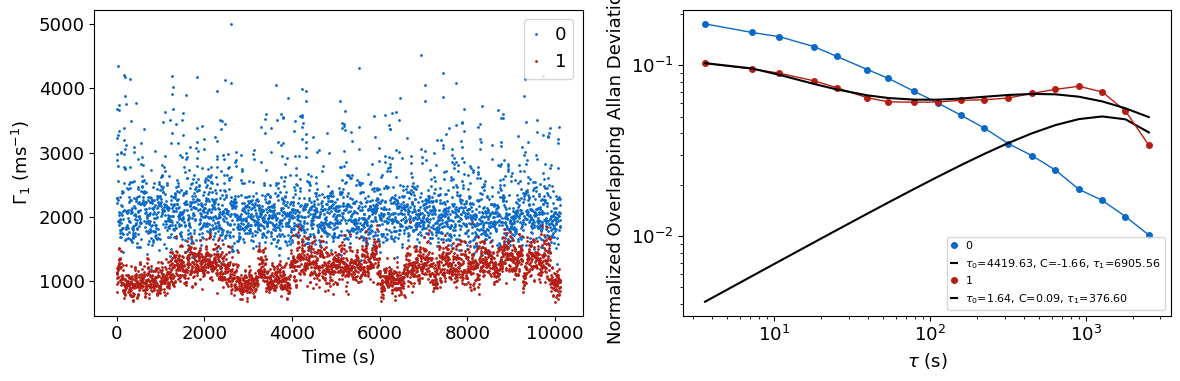

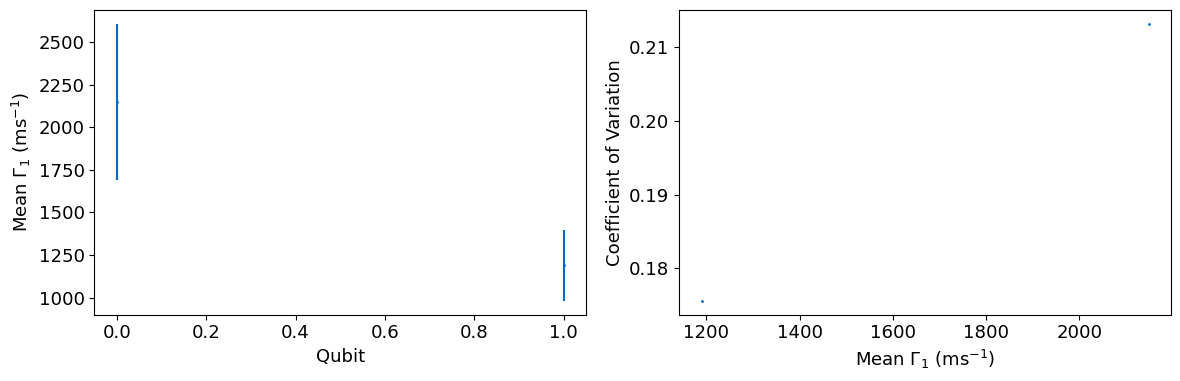

In [28]:
allan.perform_analysis(tt, param='Gamma1', save_path=csv_pth, tracking_id=tracking_id)

## Allan analysis (allantools)

Enhanced Allan deviation analysis using the `allantools` package.

### Deviation types

| Abbreviation | Name | Description |
|---|---|---|
| **ADEV** | Allan Deviation | Standard two-sample deviation. Most common stability measure. |
| **OADEV** | Overlapping Allan Deviation | Uses overlapping samples for better confidence at long tau. Same expectation as ADEV but lower variance. |
| **MDEV** | Modified Allan Deviation | Can distinguish white PM from flicker PM noise (ADEV cannot). |
| **HDEV** | Hadamard Deviation | Insensitive to linear frequency drift — useful when drift dominates. |
| **OHDEV** | Overlapping Hadamard Deviation | Overlapping version of HDEV. |
| **TDEV** | Time Deviation | Derived from MDEV; characterizes time stability rather than frequency stability. |
| **TOTDEV** | Total Deviation | Extends analysis to longer tau by reflecting data at boundaries. |

### Noise types (from log-log slope of ADEV vs tau)

| Abbreviation | Name | ADEV slope | Physical origin (qubit context) |
|---|---|---|---|
| **WPM** | White Phase Modulation | -1 | Measurement noise, digitization |
| **FPM** | Flicker Phase Modulation | -1 (same as WPM for ADEV) | Low-frequency measurement artifacts |
| **WFM** | White Frequency Modulation | -1/2 | Uncorrelated shot-to-shot fluctuations (e.g. photon shot noise, thermal noise) |
| **FFM** | Flicker Frequency Modulation | 0 (flat) | 1/f noise — TLS defects, charge noise, flux noise |
| **RWFM** | Random Walk Frequency Modulation | +1/2 | Diffusive drift — slow temperature or field drifts |

A slope that flattens or rises at long tau typically indicates correlated (1/f) or drifting noise, while a -1/2 slope indicates white (uncorrelated) fluctuations.


Gamma1


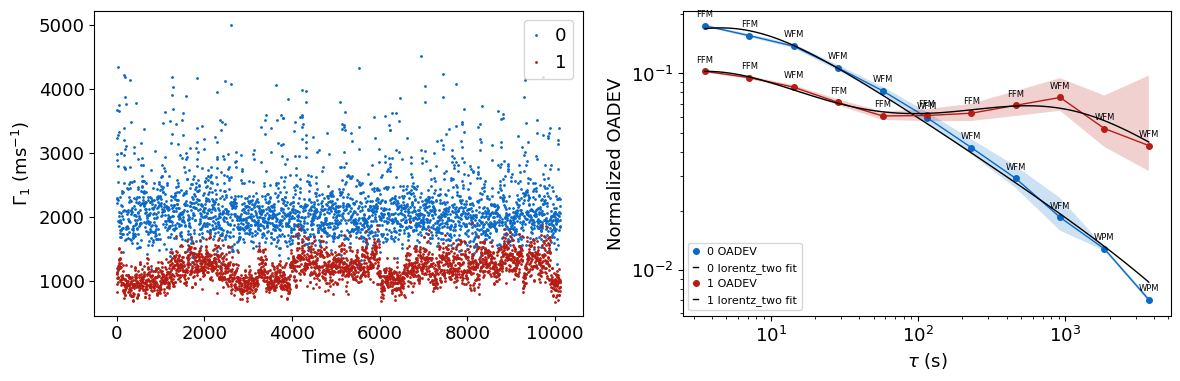

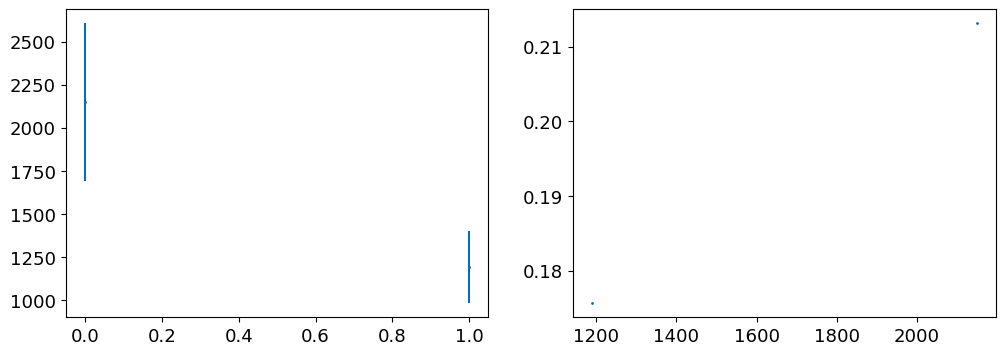


t1


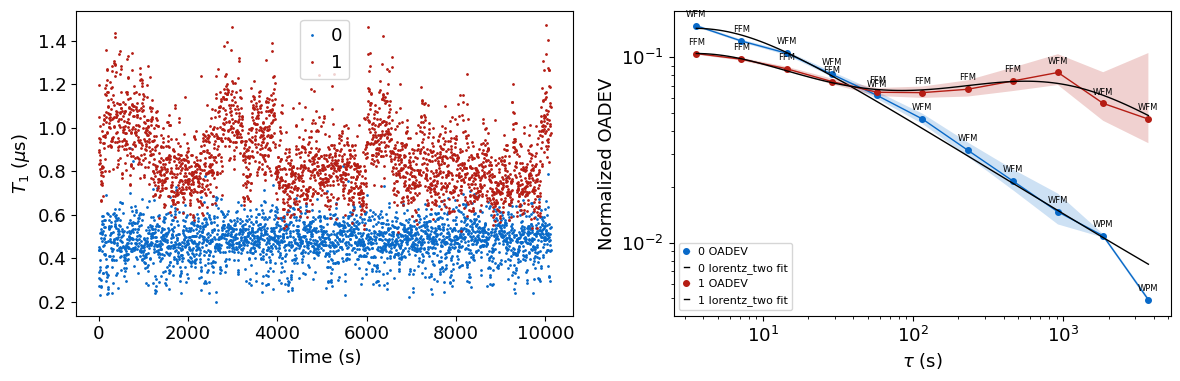

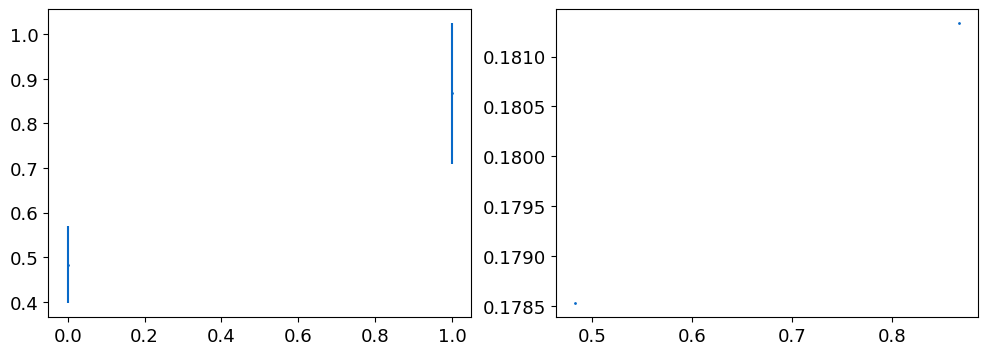


f_ge


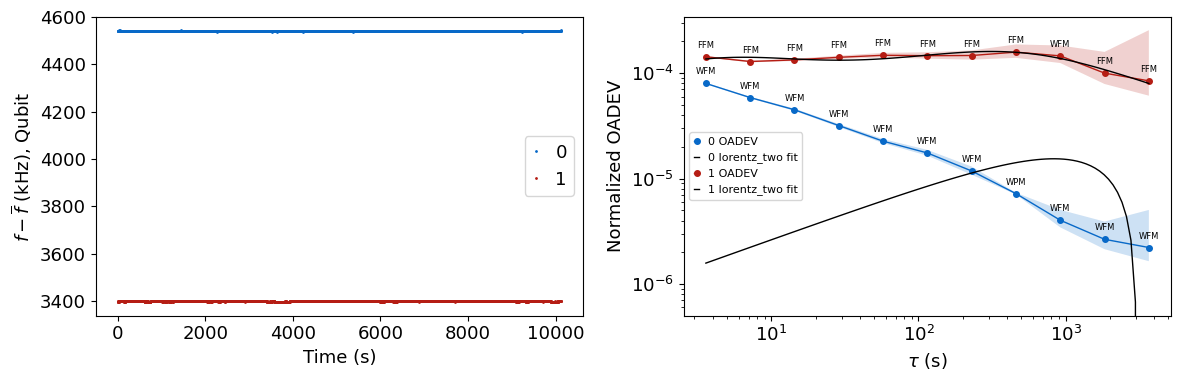

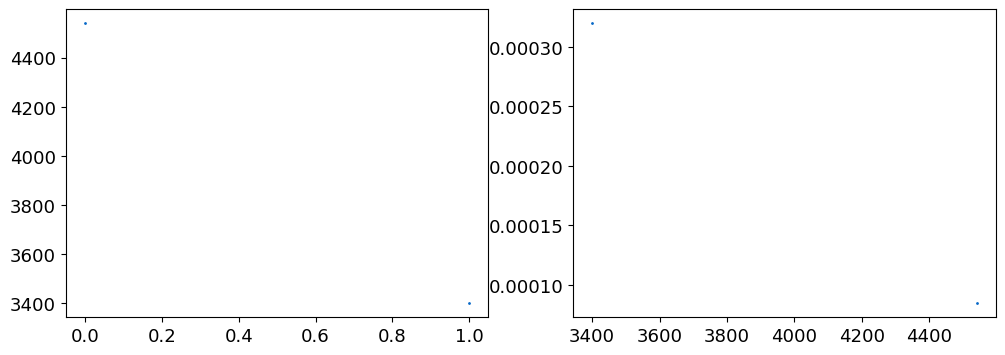

In [29]:
from slab_qick_calib.analysis.allan_at import perform_analysis_at, plot_deviation_comparison

# Full analysis per parameter with OADEV + fit
for param in ['Gamma1', 't1', 'f_ge']:
    print(f"\n{'='*60}\n{param}\n{'='*60}")
    perform_analysis_at(
        tt, param=param,
        dev_types=('oadev',), taus='octave',
        fit_models=('lorentz_two',),
        show_ci=True, show_noise_id=True,
    )

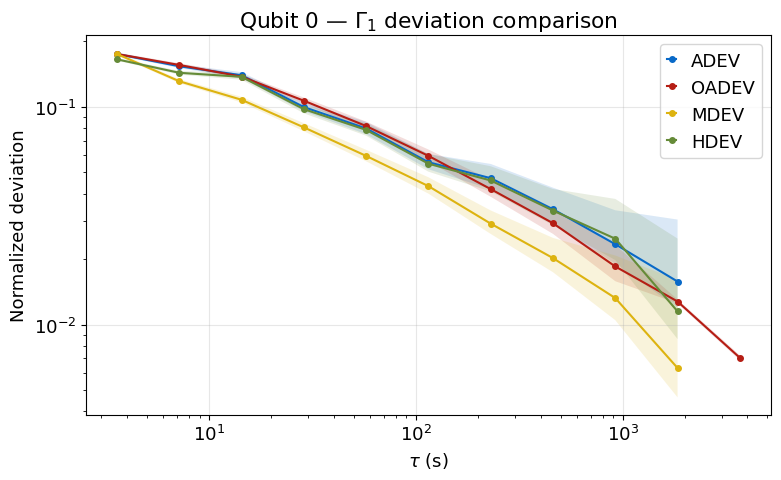

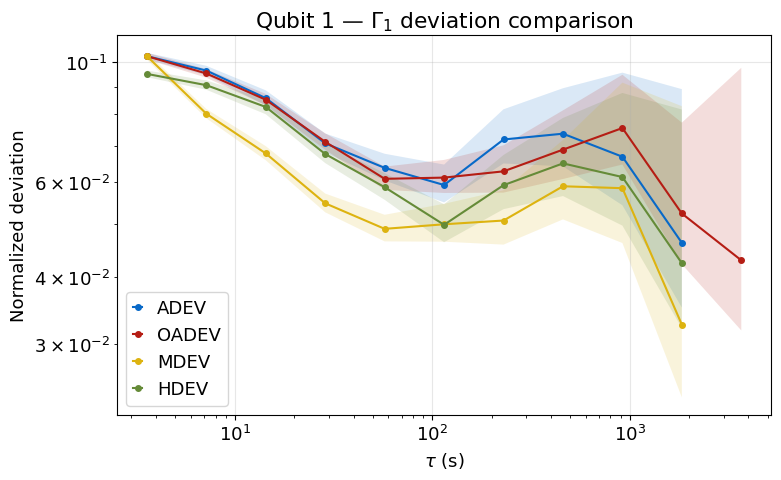

In [30]:
# Compare deviation types (ADEV, OADEV, MDEV, HDEV) for Gamma1
for qi in range(len(tt)):
    data = np.array(tt[qi]['Gamma1'])
    times = np.array(tt[qi]['time'])
    rate = 1.0 / np.mean(np.diff(times))
    plot_deviation_comparison(
        data, rate=rate,
        dev_types=('adev', 'oadev', 'mdev', 'hdev'),
        taus='octave', show_ci=True,
        title=f'Qubit {qi} — $\\Gamma_1$ deviation comparison',
    )
    plt.show()

## Time series and histograms

Number of bad inds for t1 is 6
Number of bad inds for tphi is 214
Number of bad inds for f_ge is 211
Number of bad inds for t1 is 0
Number of bad inds for tphi is 1473
Number of bad inds for f_ge is 598


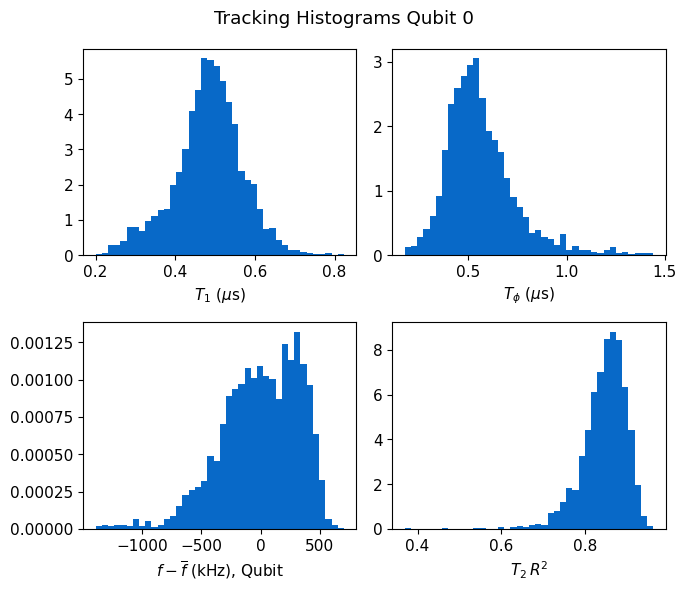

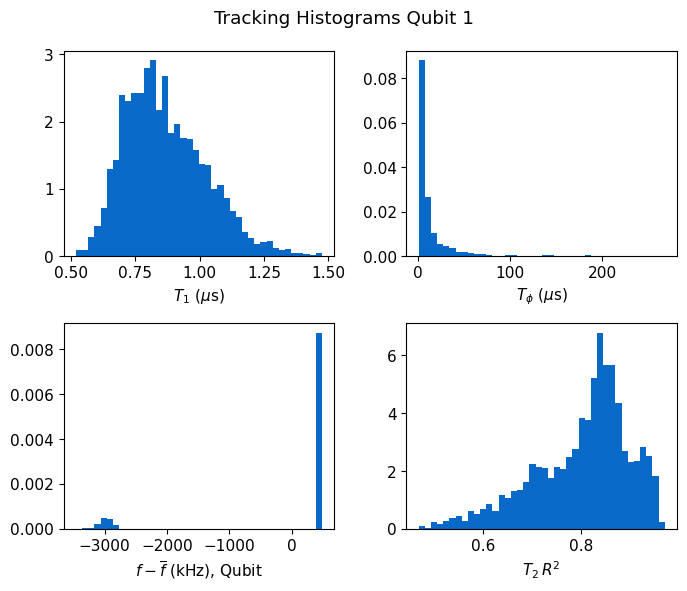

In [31]:
collections.plot_all(tt, param_keys=['t1', 'tphi', 'f_ge', 't2_r2'], save_path=csv_pth, tracking_id=tracking_id)
plt.show()

Number of bad inds for Gamma1 is 23
Number of bad inds for Gamma2 is 219
Number of bad inds for Gammaphi is 218
Number of bad inds for f_ge is 211
Number of bad inds for Gamma1 is 0
Number of bad inds for Gamma2 is 601
Number of bad inds for Gammaphi is 1460
Number of bad inds for f_ge is 598


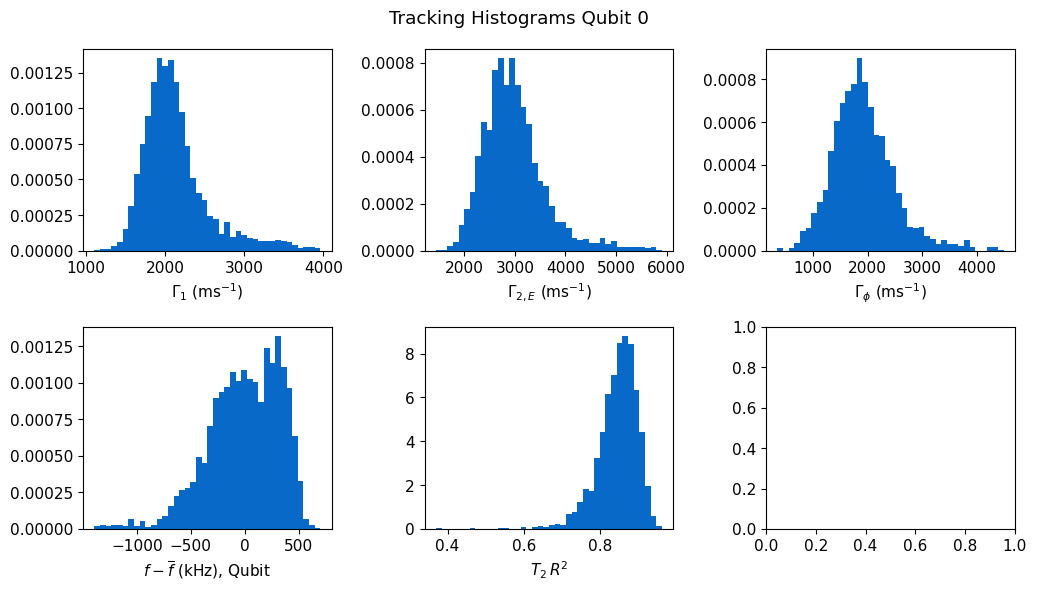

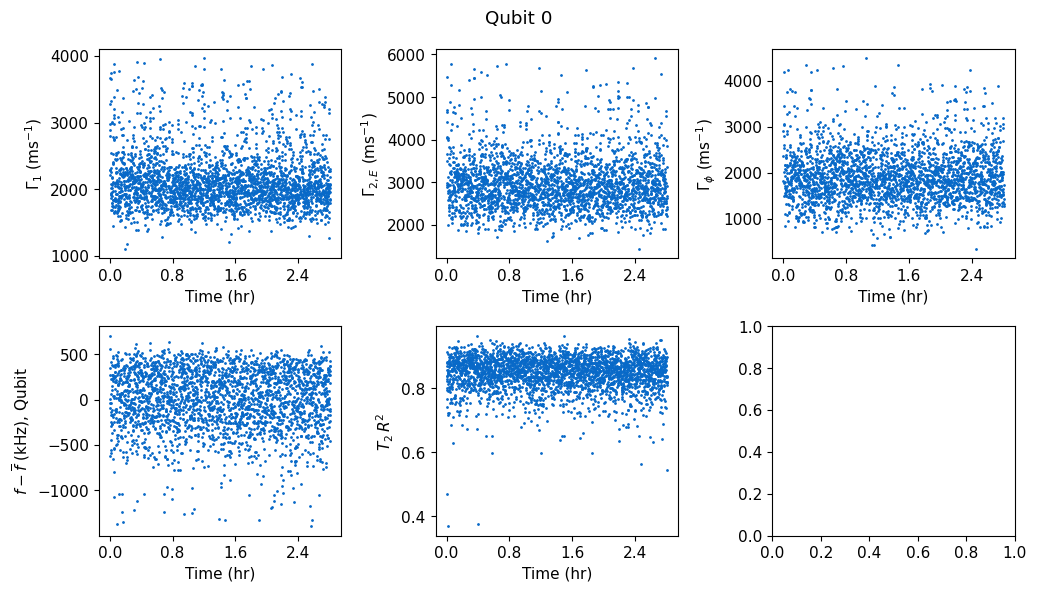

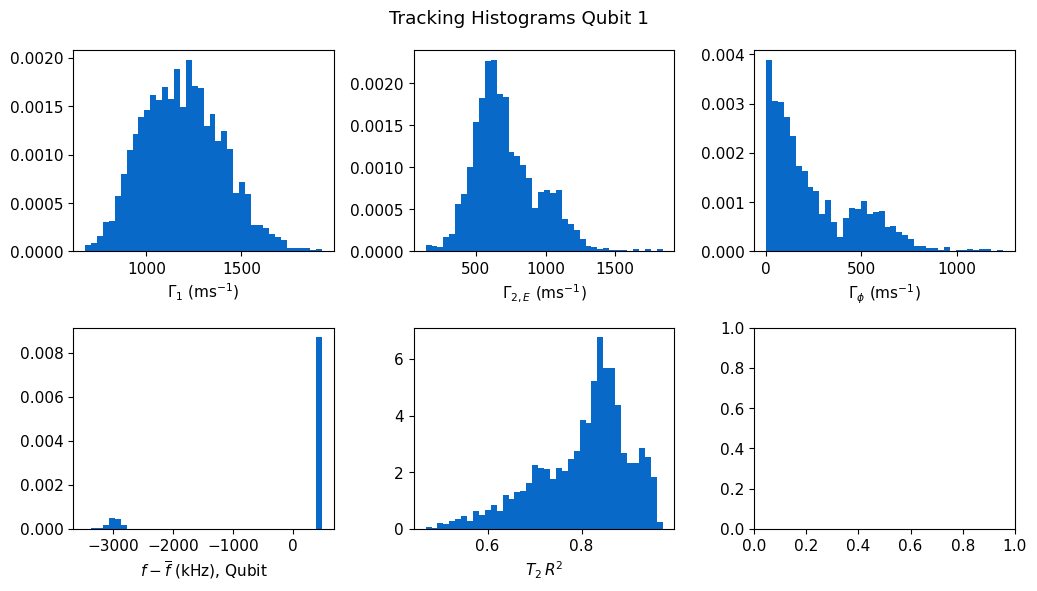

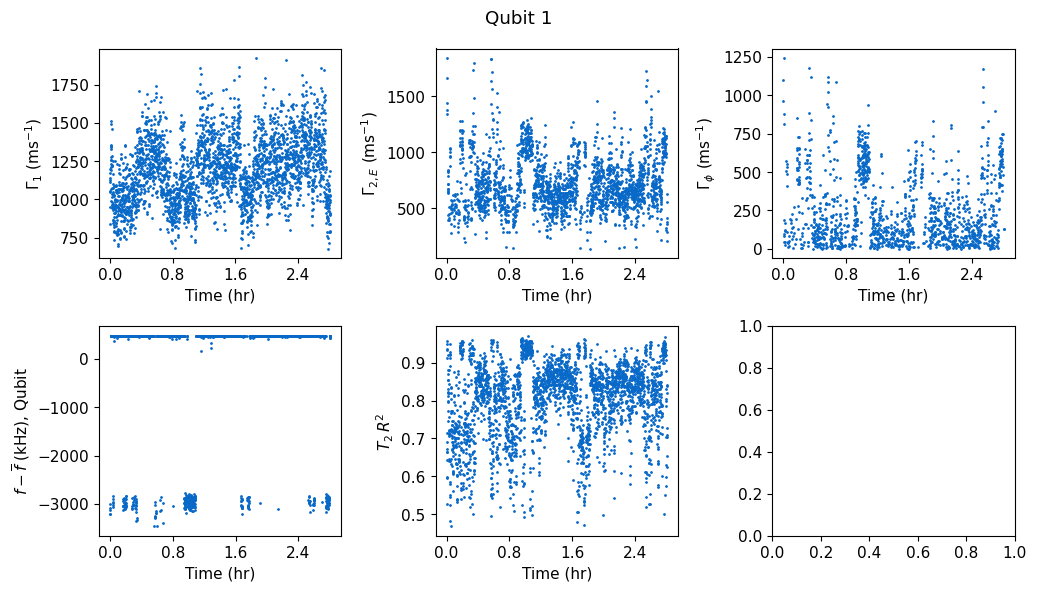

In [32]:
collections.plot_all(tt, param_keys=['Gamma1', 'Gamma2', 'Gammaphi', 'f_ge','t2_r2'], plot_time=True, save_path=csv_pth, tracking_id=tracking_id)
plt.show()

## Violin plots

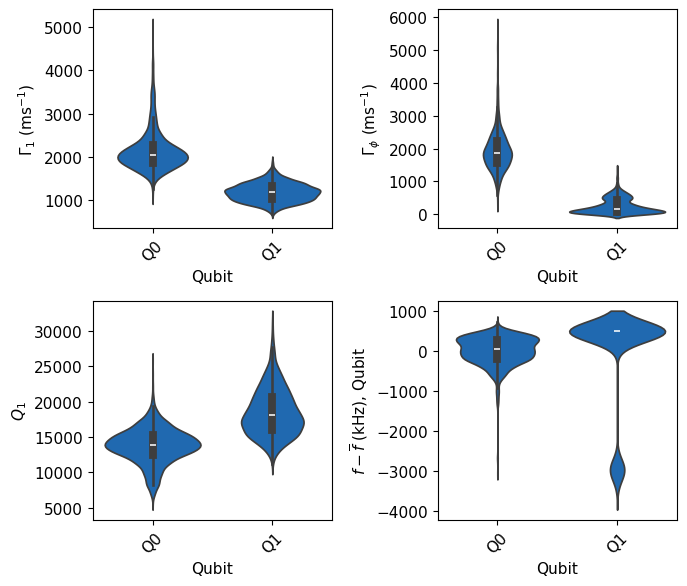

In [33]:
collections.plot_violin(tt, param_keys=['Gamma1', 'Gammaphi', 'q', 'f_ge'], csv_path=csv_pth)
plt.show()

## Power Spectral Density Analysis

Median time between measurements: 3.6 s
Sampling frequency: 0.2793 Hz

Analyzing Gamma1...


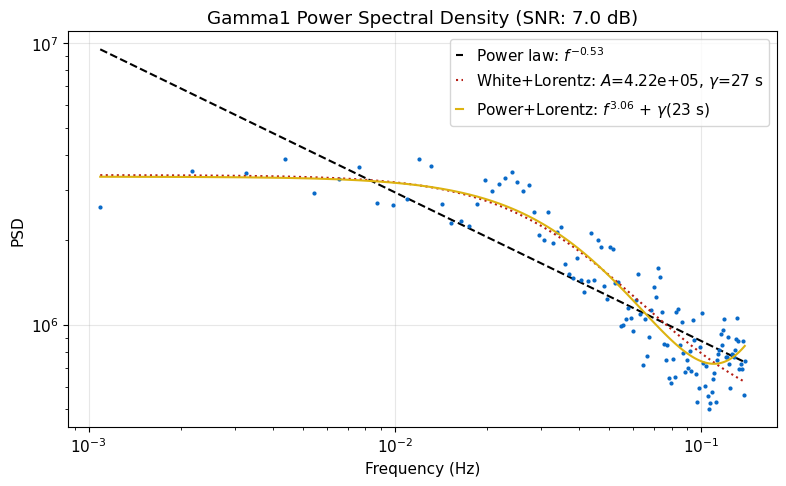

Peak frequency: 1.2000e-02 Hz (Period: 83.3 s)
Total power: 2.0352e+05
SNR: 7.0 dB

Analyzing Gammaphi...


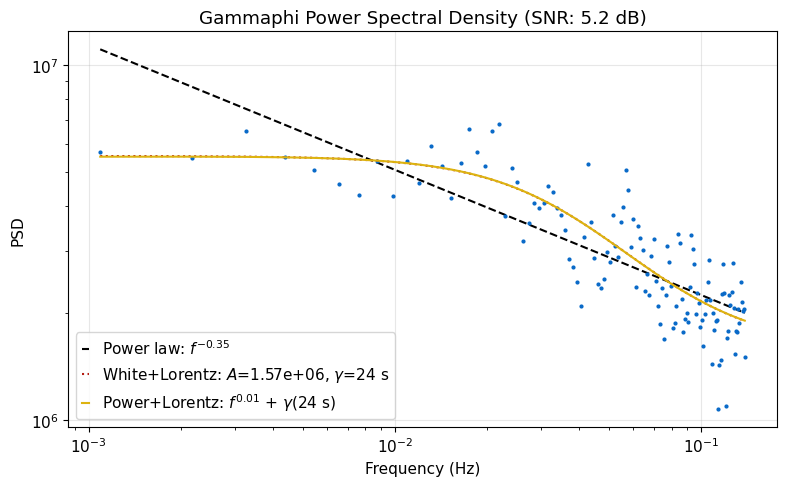

Peak frequency: 2.1818e-02 Hz (Period: 45.8 s)
Total power: 4.2769e+05
SNR: 5.2 dB

Analyzing f_ge...


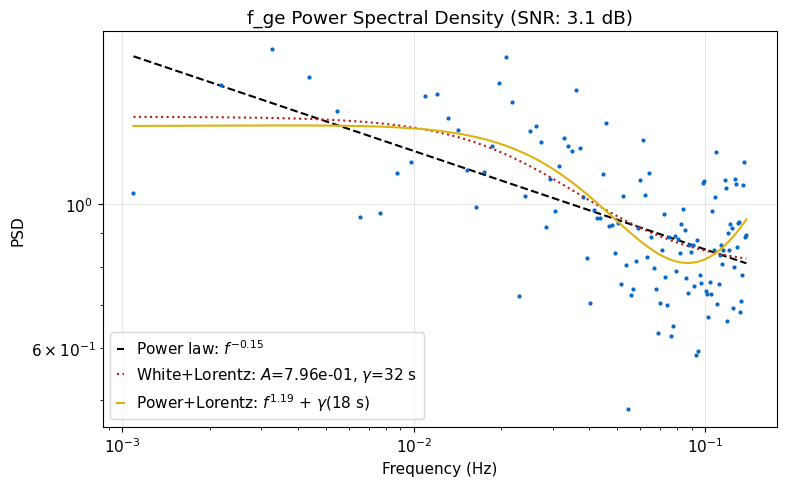

Peak frequency: 3.2727e-03 Hz (Period: 305.6 s)
Total power: 1.3436e-01
SNR: 3.1 dB

Analyzing t1...


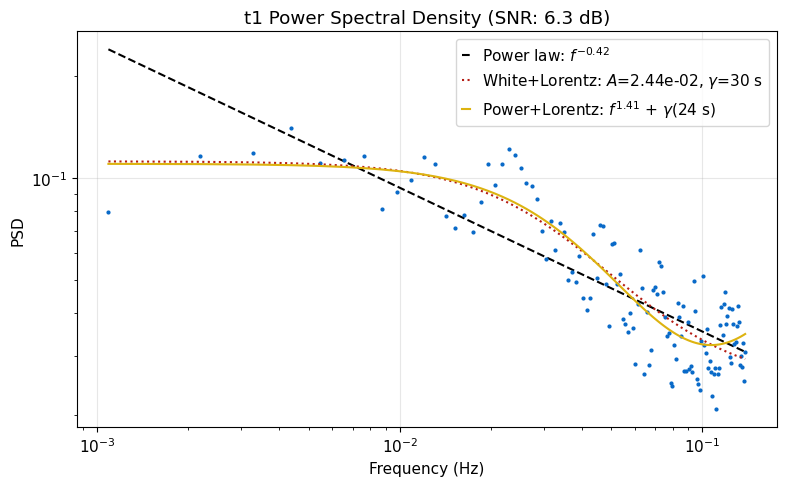

Peak frequency: 4.3636e-03 Hz (Period: 229.2 s)
Total power: 7.2962e-03
SNR: 6.3 dB


In [34]:
from slab_qick_calib.analysis.time_series import analyze_qubit_psd

# Calculate sampling frequency from timestamps
timestamps = tt[0]['time']
dt = np.median(np.diff(timestamps))  # median time between measurements (in seconds)
fs = 1 / dt  # sampling frequency in Hz

print(f"Median time between measurements: {dt:.1f} s")
print(f"Sampling frequency: {fs:.4f} Hz")

# Analyze PSD for different parameters
params_to_analyze = ['Gamma1', 'Gammaphi', 'f_ge', 't1']

for param in params_to_analyze:
    if param in tt[0]:
        data = tt[0][param]
        print(f"\n{'='*60}")
        print(f"Analyzing {param}...")
        results = analyze_qubit_psd(
            data,
            fs=fs,
            parameter_name=param,
            qubit_id=0,
            plot=True,
            save_path=csv_pth,
            tracking_id=tracking_id,
        )
        if results:
            print(f"Peak frequency: {results['peak_freq']:.4e} Hz (Period: {1/results['peak_freq']:.1f} s)")
            print(f"Total power: {results['total_power']:.4e}")
            print(f"SNR: {results['snr_db']:.1f} dB")

## Parameter vs MXC temperature

In [35]:
collections.plot_vs_temperature(tt, param_keys=['t1', 'tphi', 'f_ge', 'Gamma1'], save_path=csv_pth, tracking_id=tracking_id)

[]

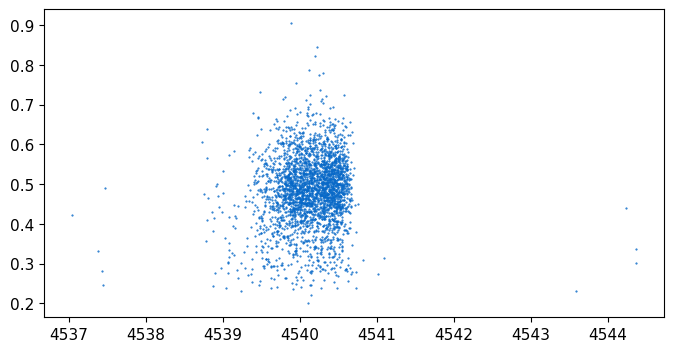

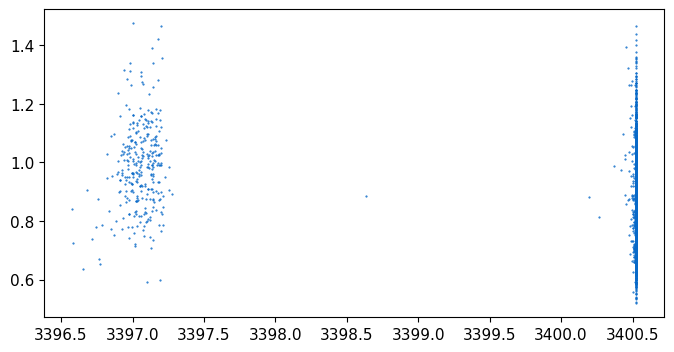

In [36]:
for t in tt:
    plt.figure()
    plt.plot(t['f_ge'], t['t1'], '.')
    plt.show()

Loaded tracking_id='2026_03_14_22_04_18.0hrs', qubits=[1, 2]
  CSV last updated: 2026-03-15 00:53:06 (8h 44m ago)


 C:\_Lib\python\qq\slab_qick_calib\analysis\allan.py: 16RuntimeWarning: overflow encountered in exp
 C:\_Lib\python\qq\slab_qick_calib\analysis\allan.py: 16RuntimeWarning: invalid value encountered in subtract
 C:\_Lib\python\qq\slab_qick_calib\analysis\allan.py: 16

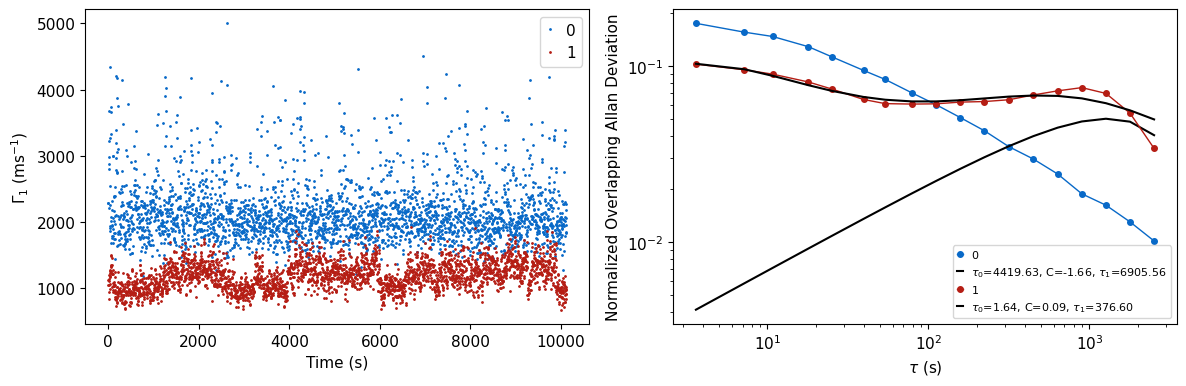

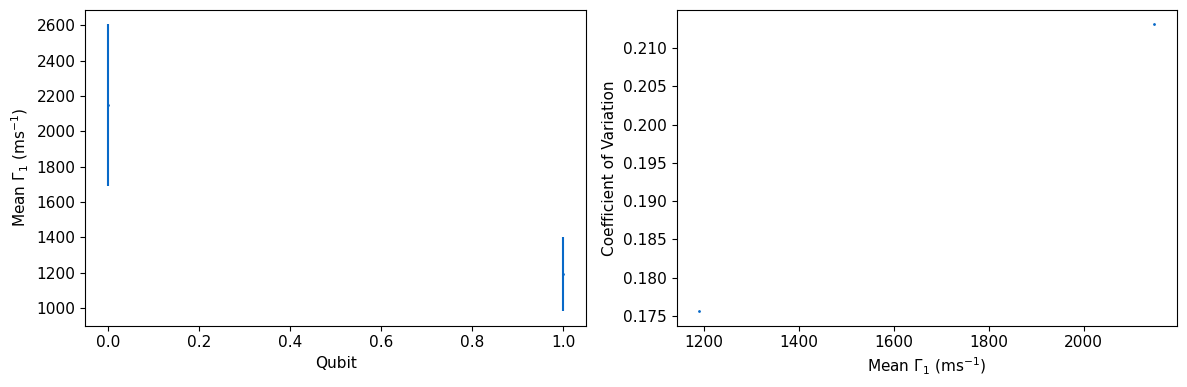

Number of bad inds for t1 is 6
Number of bad inds for tphi is 214
Number of bad inds for f_ge is 211
Number of bad inds for t1 is 0
Number of bad inds for tphi is 1473
Number of bad inds for f_ge is 598


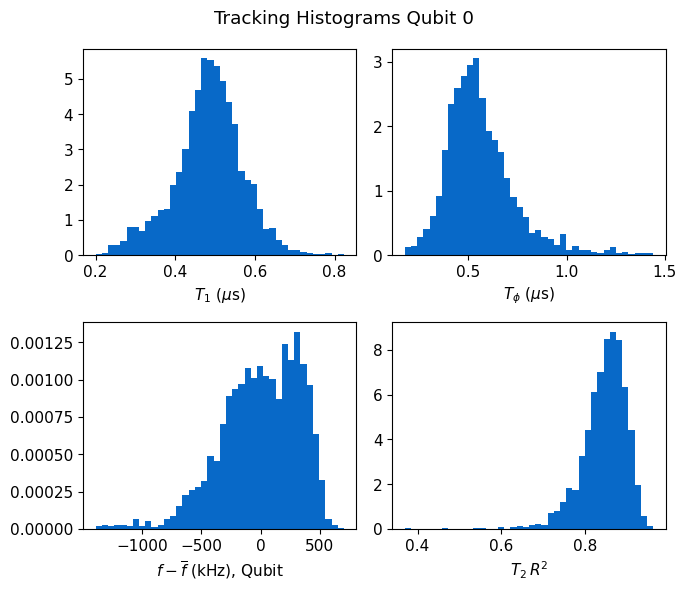

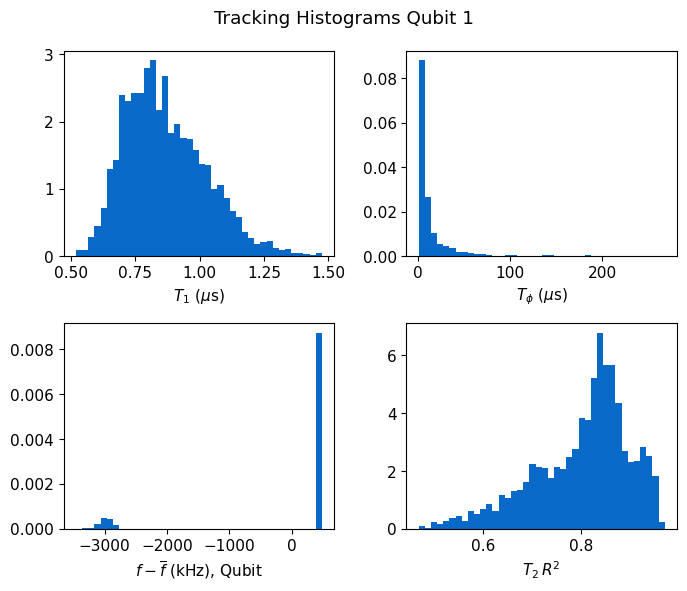

Loaded tracking_id='2026_03_14_22_04_18.0hrs', qubits=[1, 2]
  CSV last updated: 2026-03-15 00:53:06 (8h 54m ago)


 C:\_Lib\python\qq\slab_qick_calib\analysis\allan.py: 16RuntimeWarning: overflow encountered in exp
 C:\_Lib\python\qq\slab_qick_calib\analysis\allan.py: 16RuntimeWarning: invalid value encountered in subtract
 C:\_Lib\python\qq\slab_qick_calib\analysis\allan.py: 16

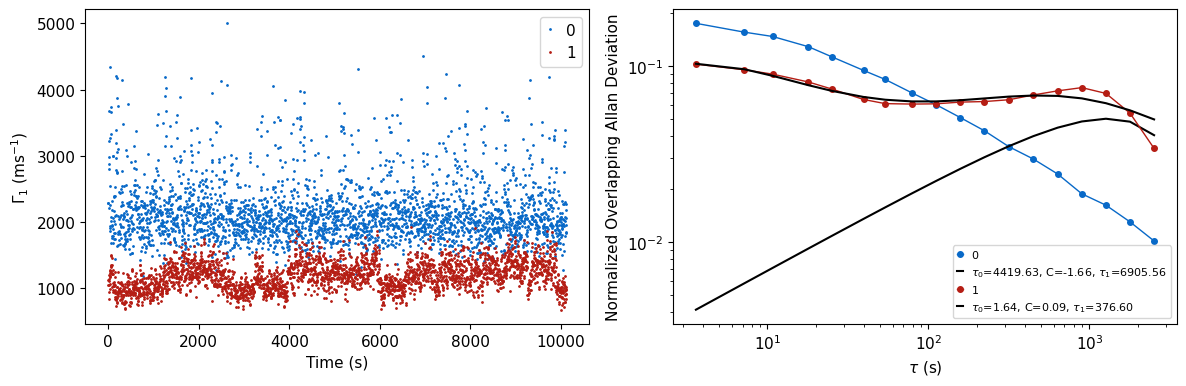

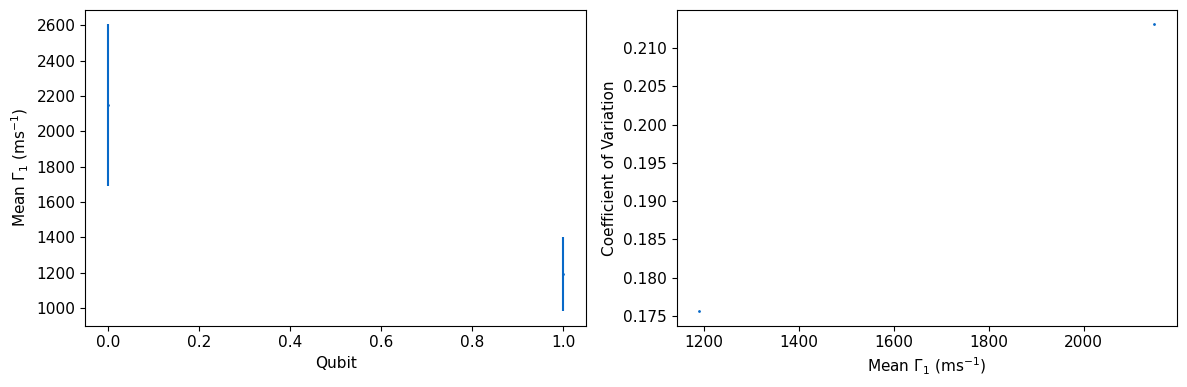

Number of bad inds for t1 is 6
Number of bad inds for tphi is 214
Number of bad inds for f_ge is 211
Number of bad inds for t1 is 0
Number of bad inds for tphi is 1473
Number of bad inds for f_ge is 598


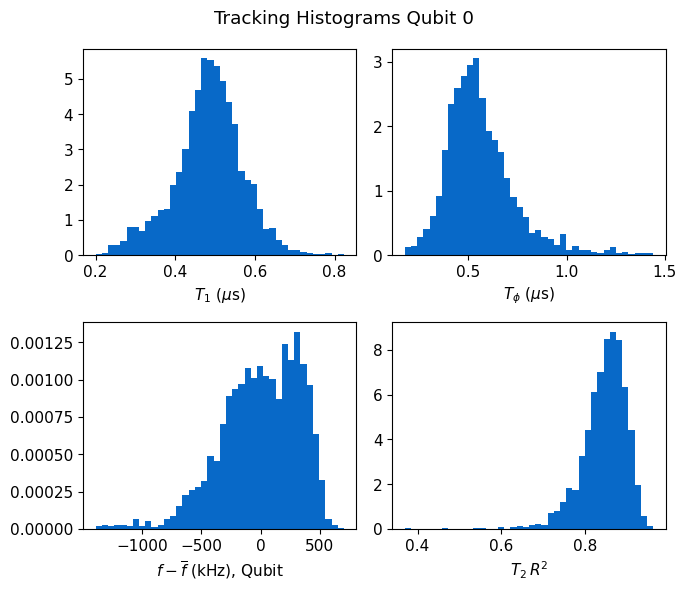

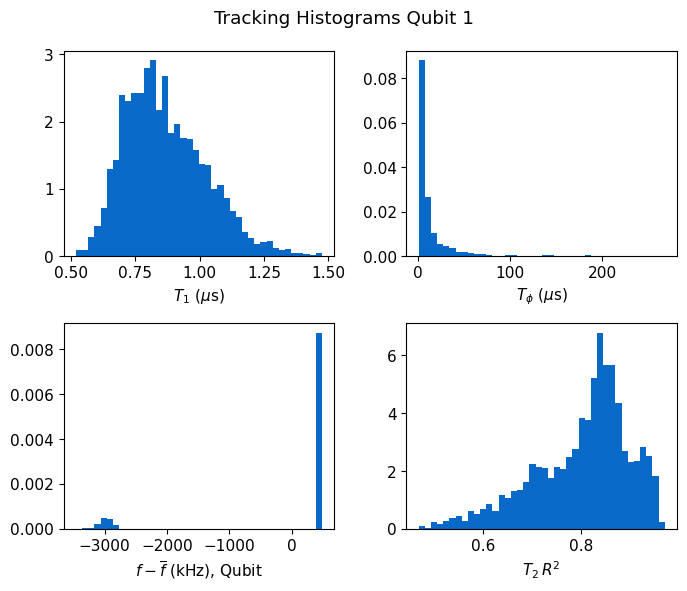

In [ ]:
import time
while True:
    tt, csv_pth, tt_stats, tracking_id = load_tracking(csv_dir)
    tt, tt_ave = collections.process_data(tt)
    tt = collections.add_losses(tt)
    allan.perform_analysis(tt, param='Gamma1', save_path=csv_pth, tracking_id=tracking_id)
    collections.plot_all(tt, param_keys=['t1', 'tphi', 'f_ge', 't2_r2'], save_path=csv_pth, tracking_id=tracking_id)
    plt.show()
    time.sleep(600)

## Save stats to model config

In [ ]:
qubit_params.stats(cfg_path, tt_stats, qubit_list)

FileNotFoundError: [Errno 2] No such file or directory: 'c:\\_Lib\\python\\qq\\slab_qick_calib\\notebooks\\..\\configs\\sample_50_rfboard_model.yml'